# This notebook loads the data ranks the cities based on individual Hydrological Risk (HR), Heat Severity (HS) and Air Quality (AQ) Components
##### Authors: Omid Emamjomehzadeh (https://www.omidemam.com/) & Berina Mina Kilicarslan
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
os.environ["OMP_NUM_THREADS"] = "1"
from pathlib import Path
import os

In [2]:
current_folder = Path.cwd().parent
os.chdir(current_folder)
print("Current folder:", current_folder)


Current folder: c:\Omid\Repos\bgipotential


In [3]:
BGIPI = pd.read_excel(r"Results\GIPI_Results.xls", header=0)
BGIPI.columns

Index(['OBJECTID_1', 'City', 'Population__US_Census', 'Area_of_City__m2_',
       'Precip___inches_', 'Normalized_P', 'Abs_P_Norm', 'F__CSO_Outfalls',
       'CSO_Cumul__Normal', 'Abs_CSO_Norm', 'P__Lot_Area__m2_',
       'P__Lot_Area_Cumul__Norm', 'Abs_PLA_Norm',
       'P__Lot_Area_per_unit_area_of_the_city', 'PLA_perarea_Abs_norm',
       'August_Night_Low', 'August_Lows_Normal', 'Abs_AugT_Norm',
       'HydroRiskAvg', 'HeatRiskAvg', 'AQAvg', 'ImpervAvg', 'HeatGeoAvg',
       'Tbl_GIPI'],
      dtype='str')

### 3 Stressors' rank

In [4]:
cols = ['City', 'HydroRiskAvg', 'HeatRiskAvg', 'AQAvg']
df = BGIPI[cols].copy()

df['HydroRisk_rank'] = df['HydroRiskAvg'].rank(ascending=False, method='min').astype(int)
df['HeatRisk_rank'] = df['HeatRiskAvg'].rank(ascending=False, method='min').astype(int)
df['AQ_rank'] = df['AQAvg'].rank(ascending=False, method='min').astype(int)


df[['City','HydroRisk_rank','HeatRisk_rank','AQ_rank']]

,City,HydroRisk_rank,HeatRisk_rank,AQ_rank
0,NYC,3,1,10
1,FtWorth,7,2,7
2,Dallas,6,3,3
3,Phoenix,16,4,5
4,Houston,4,5,1
5,SanAntonio,9,6,14
6,Philadelphia,2,7,13
7,Austin,10,8,18
8,Jacksonville,18,9,19
9,Chicago,1,10,9


### Plt

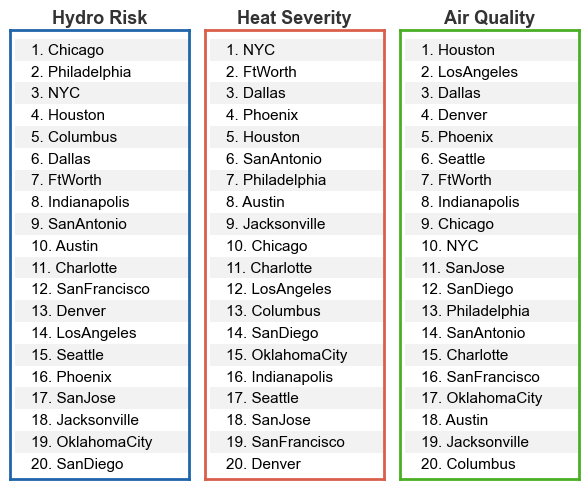

In [5]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']

components = ['HydroRiskAvg', 'HeatRiskAvg', 'AQAvg']
titles = ['Hydro Risk', 'Heat Severity', 'Air Quality']

gipi_colors = {
    'Hydrology': '#2065AB',
    'Heat': '#D95F4B',
    'Air Quality': '#4AAF25'
}

fig, axes = plt.subplots(1, 3, figsize=(6, 5))
row_colors = ['#f2f2f2', '#ffffff']

for ax, component, title, color in zip(axes, components, titles, gipi_colors.values()):
    sorted_cities = df.sort_values(component, ascending=False)['City'].reset_index(drop=True)

    ax.set_facecolor('#ffffff')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=5, color='#333333')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color(color)

    num_cities = len(sorted_cities)
    band_top = 0.98
    band_bottom = 0.01
    band_height = (band_top - band_bottom) / num_cities

    for i, city in enumerate(sorted_cities):
        y0 = band_top - (i + 1) * band_height
        ax.add_patch(
            Rectangle(
                (0.03, y0), # (x, y) starting coordinate
                0.98, # THIS IS THE WIDTH (80% of the column width)
                band_height,
                transform=ax.transAxes,
                facecolor=row_colors[i % 2],
                edgecolor='none',
                zorder=0
            )
        )

        y_pos = y0 + band_height / 2
        ax.text(
            0.12,
            y_pos,
            f"{i + 1}. {city}",
            fontsize=11,
            color='#000000',
            fontweight='normal',
            va='center',
            transform=ax.transAxes,
            zorder=1
        )


plt.tight_layout()
#plt.savefig('BGIPI_risk_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

